In [ ]:
import kagglehub


# Descargar la ultima version
ruta = kagglehub.dataset_download("victorlemosml/refuge2")

print("Path to dataset files:", ruta)

Using Colab cache for faster access to the 'refuge2' dataset.
Path to dataset files: /kaggle/input/refuge2


In [ ]:
!pip install segmentation-models-pytorch albumentations
import os
import glob
import cv2
import numpy as np
from torch.utils.data import Dataset, DataLoader
import albumentations as A


import random
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split

import torch.optim as optim
from tqdm import tqdm
import torch.cuda.amp as amp


from typing import Dict, List, Tuple, Optional
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import json
from datetime import datetime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.1 MB/s eta 0:00:00


In [ ]:
ROOT = "/kaggle/input/refuge2/REFUGE2/"

In [ ]:
#Esa funcion construye las rutas de las carpetas de imagenes y mascaras, y de
#devuelve dos listas ordenadas
def make_pairs(split):
    img_dir = os.path.join(ROOT, split, "images")
    mask_dir = os.path.join(ROOT, split, "mask")

    # Debug: verifica que el fichero realmente exista anteds de globalizar
    if not os.path.exists(img_dir):
        print(f"ERROR: Directory not found: {img_dir}")

        parent = os.path.join(ROOT, split)
        if os.path.exists(parent):
            print(f"But the parent folder '{parent}' contains: {os.listdir(parent)}")
        return [], []
#ordena las listas alfabeticamente para emparejar archivo por archivo
    imgs = sorted(glob.glob(os.path.join(img_dir, "*")))
    masks = sorted(glob.glob(os.path.join(mask_dir, "*")))

    print("IMÁGENES:", imgs)
    print("MÁSCARAS:", masks)
    return imgs, masks

### PREPROCESADO

In [ ]:

class FundusSegDataset(Dataset):
    def __init__(self, images, masks, transforms=None, img_size=512):
        self.images = images
        self.masks = masks
        self.transforms = transforms
        self.img_size = img_size

    def __len__(self):
        return len(self.images)

    def clean_fundus_image(self, img):
        """
        Exactly the same cleaning function you provided.
        """
        # 1. VESSEL SUPPRESSION

        kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        img_closed = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel_small)
        img_closed = cv2.morphologyEx(img_closed, cv2.MORPH_CLOSE, kernel_large)

        # 2. GAUSSIAN BLUR
        img_blurred = cv2.GaussianBlur(img_closed, (3, 3), 0)
        background = cv2.GaussianBlur(img_blurred, (31, 31), 0)
        img_normalized = cv2.subtract(img_blurred, background)
        img_normalized = cv2.add(img_normalized, 128)
        img_normalized = np.clip(img_normalized, 0, 255).astype(np.uint8)

        # 4. CONTRAST ENHANCEMENT (CLAHE)
        lab = cv2.cvtColor(img_normalized, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit= 2.5, tileGridSize=(8, 8))
        l = clahe.apply(l)
        lab = cv2.merge((l, a, b))
        img_final = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

        return img_final

    def __getitem__(self, idx):
        # --- 1. Cargar datos ---
        img_raw = cv2.imread(self.images[idx])
        img_raw = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.masks[idx], cv2.IMREAD_UNCHANGED)
        if len(mask.shape) == 3:
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)

       # --- 2. Redimensionado ---

        img_raw = cv2.resize(img_raw, (self.img_size, self.img_size))
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

     # --- 3. Preparar canales ---

        green_channel = img_raw[:, :, 1]


        img_cleaned = self.clean_fundus_image(img_raw)
        # --- 4. Ensamblado (4 Canales) ---

        green_expanded = np.expand_dims(green_channel, axis=-1)


        final_input = np.concatenate([img_cleaned, green_expanded], axis=-1)

        # --- 5. Mapeo de clases ---
        mask_class = np.zeros_like(mask, dtype=np.uint8)
        mask_class[mask == 255] = 0  # Background
        mask_class[mask == 128] = 1  # Disc
        mask_class[mask == 0] = 2  # Cup

      # --- 6. Aumentación ---

        if self.transforms:
            augmented = self.transforms(image=final_input, mask=mask_class)
            final_input = augmented["image"]
            mask_class = augmented["mask"]

        final_input = final_input.astype(np.float32) / 255.0

        num_classes = 3
        mask_onehot = np.zeros((num_classes, self.img_size, self.img_size), dtype=np.float32)
        for c in range(num_classes):
            mask_onehot[c] = (mask_class == c).astype(np.float32)

        final_input = np.transpose(final_input, (2, 0, 1))

        return torch.tensor(final_input, dtype=torch.float32), torch.tensor(mask_onehot, dtype=torch.float32)

In [ ]:
train_transforms = A.Compose([
    A.Resize(height=512, width=512),

    # --- 1. Geometría ---

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),


     A.ShiftScaleRotate(
        shift_limit=0.05,       # Pequeña traslación
        scale_limit=0.1,       # Zoom moderado dentro/fuera
        rotate_limit=180,      # Cobertura completa de rotación
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),
     A.OneOf([

        A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=1.0),


        A.MultiplicativeNoise(multiplier=(0.9, 1.1), elementwise=True, p=1.0),
    ], p=0.5),
     A.CoarseDropout(
        num_holes_range=(5, 8),
        hole_height_range=(10, 20),
        hole_width_range=(10, 20),
        p=0.2
    ),
])


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
print("--- RELOADING DATA ---")
train_images, train_masks = make_pairs("train")
val_images, val_masks     = make_pairs("val")
test_images, test_masks   = make_pairs("test")

--- RELOADING DATA ---
IMÁGENES: ['/kaggle/input/refuge2/REFUGE2/train/images/g0001.jpg', '/kaggle/input/refuge2/REFUGE2/train/images/g0002.jpg', '/kaggle/input/refuge2/REFUGE2/train/images/g0003.jpg', '/kaggle/input/refuge2/REFUGE2/train/images/g0004.jpg', '/kaggle/input/refuge2/REFUGE2/train/images/g0005.jpg', '/kaggle/input/refuge2/REFUGE2/train/images/g0006.jpg', '/kaggle/input/refuge2/REFUGE2/train/images/g0007.jpg', '/kaggle/input/refuge2/REFUGE2/train/images/g0008.jpg', '/kaggle/input/refuge2/REFUGE2/train/images/g0009.jpg', '/kaggle/input/refuge2/REFUGE2/train/images/g0010.jpg', '/kaggle/input/refuge2/REFUGE2/train/images/g0011.jpg', '/kaggle/input/refuge2/REFUGE2/train/images/g0012.jpg', '/kaggle/input/refuge2/REFUGE2/train/images/g0013.jpg', '/kaggle/input/refuge2/REFUGE2/train/images/g0014.jpg', '/kaggle/input/refuge2/REFUGE2/train/images/g0015.jpg', '/kaggle/input/refuge2/REFUGE2/train/images/g0016.jpg', '/kaggle/input/refuge2/REFUGE2/train/images/g0017.jpg', '/kaggle/input

In [ ]:
val_transforms = A.Compose([])
train_ds = FundusSegDataset(train_images, train_masks, transforms=train_transforms, img_size=512)
val_ds   =  FundusSegDataset(val_images, val_masks, transforms=val_transforms, img_size=512)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
class TrainingTracker:
    """Track training metrics and losses"""

    def __init__(self, save_dir='training_logs'):
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)

        self.history = {
            'train_loss': [],
            'train_dice': [],
            'train_iou': [],
            'val_loss': [],
            'val_dice': [],
            'val_iou': [],
            'val_accuracy': [],
            'learning_rate': [],
            'epoch': []
        }
    def update(self, epoch, train_loss, train_dice, train_iou,
               val_loss, val_dice, val_iou, val_accuracy, lr):
        """Update history with new epoch metrics"""
        self.history['epoch'].append(epoch)
        self.history['train_loss'].append(train_loss)
        self.history['train_dice'].append(train_dice)
        self.history['train_iou'].append(train_iou)
        self.history['val_loss'].append(val_loss)
        self.history['val_dice'].append(val_dice)
        self.history['val_iou'].append(val_iou)
        self.history['val_accuracy'].append(val_accuracy)
        self.history['learning_rate'].append(lr)
    def save(self, filename='training_history.json'):
        """Save history to JSON file"""
        filepath = os.path.join(self.save_dir, filename)
        with open(filepath, 'w') as f:
            json.dump(self.history, f, indent=4)
        print(f"✓ Training history saved to: {filepath}")

    def plot_training_curves(self, save_path=None):
        """Plot comprehensive training curves"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        epochs = self.history['epoch']

       # 1. Curvas de pérdida (Loss)
        axes[0, 0].plot(epochs, self.history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
        axes[0, 0].plot(epochs, self.history['val_loss'], 'r-s', label='Val Loss', linewidth=2, markersize=4)
        axes[0, 0].set_xlabel('Epoch', fontsize=11)
        axes[0, 0].set_ylabel('Loss', fontsize=11)
        axes[0, 0].set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
        axes[0, 0].legend(fontsize=10)
        axes[0, 0].grid(True, alpha=0.3)
        train_losses = self.history['train_loss']
        val_losses = self.history['val_loss']
        for i in range(1, len(val_losses)):
            if val_losses[i] > val_losses[i-1] and train_losses[i] < train_losses[i-1]:
                axes[0, 0].axvline(x=epochs[i], color='orange', linestyle='--', alpha=0.5)
                axes[0, 0].text(epochs[i], max(val_losses), 'Possible\nOverfit',
                ha='center', fontsize=9, color='orange')
                break
        axes[0, 1].plot(epochs, self.history['train_dice'], 'b-o', label='Train Dice', linewidth=2, markersize=4)
        axes[0, 1].plot(epochs, self.history['val_dice'], 'r-s', label='Val Dice', linewidth=2, markersize=4)
        axes[0, 1].set_xlabel('Epoch', fontsize=11)
        axes[0, 1].set_ylabel('Dice Score', fontsize=11)
        axes[0, 1].set_title('Dice Score Progress', fontsize=13, fontweight='bold')
        axes[0, 1].legend(fontsize=10)
        axes[0, 1].grid(True, alpha=0.3)
        axes[0, 1].set_ylim(0, 1)

        axes[1, 0].plot(epochs, self.history['train_iou'], 'b-o', label='Train IoU', linewidth=2, markersize=4)
        axes[1, 0].plot(epochs, self.history['val_iou'], 'r-s', label='Val IoU', linewidth=2, markersize=4)
        axes[1, 0].set_xlabel('Epoch', fontsize=11)
        axes[1, 0].set_ylabel('IoU Score', fontsize=11)
        axes[1, 0].set_title('IoU Score Progress', fontsize=13, fontweight='bold')
        axes[1, 0].legend(fontsize=10)
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].set_ylim(0, 1)

        axes[1, 1].plot(epochs, self.history['learning_rate'], 'g-o', linewidth=2, markersize=4)
        axes[1, 1].set_xlabel('Epoch', fontsize=11)
        axes[1, 1].set_ylabel('Learning Rate', fontsize=11)
        axes[1, 1].set_title('Learning Rate Schedule', fontsize=13, fontweight='bold')
        axes[1, 1].set_yscale('log')
        axes[1, 1].grid(True, alpha=0.3)

        plt.suptitle('Training Progress', fontsize=16, fontweight='bold', y=0.995)
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"✓ Training curves saved to: {save_path}")

        plt.show()

    def print_summary(self):
        """Print training summary"""
        print("\n" + "="*70)
        print("TRAINING SUMMARY")
        print("="*70)

        best_val_dice_idx = self.history['val_dice'].index(max(self.history['val_dice']))
        best_epoch = self.history['epoch'][best_val_dice_idx]

        print(f"\nBest Validation Dice: {max(self.history['val_dice']):.4f} at Epoch {best_epoch}")
        print(f"Final Train Loss:     {self.history['train_loss'][-1]:.4f}")
        print(f"Final Val Loss:       {self.history['val_loss'][-1]:.4f}")
        print(f"Final Train Dice:     {self.history['train_dice'][-1]:.4f}")
        print(f"Final Val Dice:       {self.history['val_dice'][-1]:.4f}")
        train_val_gap = self.history['train_dice'][-1] - self.history['val_dice'][-1]
        print(f"\nTrain-Val Dice Gap:   {train_val_gap:.4f}")

        if train_val_gap < 0.05:
            print("Status: ✓ No overfitting detected")
        elif train_val_gap < 0.10:
            print("Status: ⚠ Slight overfitting")
        else:
            print("Status: ✗ Significant overfitting detected")
def calculate_dice_score_batch(pred, target, num_classes=3):
    """Calculate average Dice score for a batch"""
    dice_scores = []

    pred_classes = torch.argmax(pred, dim=1)
    target_classes = torch.argmax(target, dim=1)
    for c in range(num_classes):
        pred_c = (pred_classes == c)
        target_c = (target_classes == c)

        intersection = (pred_c & target_c).float().sum()
        union = pred_c.float().sum() + target_c.float().sum()

        if union > 0:
            dice = (2.0 * intersection) / union
            dice_scores.append(dice.item())

    return np.mean(dice_scores)

def calculate_iou_batch(pred, target, num_classes=3):
    """Calculate average IoU for a batch"""
    iou_scores = []

    pred_classes = torch.argmax(pred, dim=1)
    target_classes = torch.argmax(target, dim=1)

    for c in range(num_classes):
        pred_c = (pred_classes == c)
        target_c = (target_classes == c)

        intersection = (pred_c & target_c).float().sum()
        union = (pred_c | target_c).float().sum()

        if union > 0:
            iou = intersection / union
            iou_scores.append(iou.item())

    return np.mean(iou_scores)


In [ ]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_everything(42)

In [ ]:
ENCODER = "resnet34"
ENCODER_WEIGHTS = "imagenet"

model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights= "imagenet",
    in_channels=3,
    classes=3,
    activation=None
)
old_conv_layer = model.encoder.conv1
print(f"Original Conv1 Weights: {old_conv_layer.weight.shape}")

new_conv_layer = nn.Conv2d(
    in_channels=4,
    out_channels=old_conv_layer.out_channels,
    kernel_size=old_conv_layer.kernel_size,
    stride=old_conv_layer.stride,
    padding=old_conv_layer.padding,
    bias=old_conv_layer.bias,
)
model.encoder.conv1 = new_conv_layer
with torch.no_grad():
    new_conv_layer.weight[:, :3, :, :] = old_conv_layer.weight
    mean_weights = torch.mean(old_conv_layer.weight, dim=1, keepdim=True)
    new_conv_layer.weight[:, 3:4, :, :] = mean_weights

print(f"New Conv1 Weights: {model.encoder.conv1.weight.shape}")
print("Surgery Successful! Model is ready for 4 channels with ImageNet knowledge.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Original Conv1 Weights: torch.Size([64, 3, 7, 7])
New Conv1 Weights: torch.Size([64, 4, 7, 7])
Surgery Successful! Model is ready for 4 channels with ImageNet knowledge.


/tmp/ipython-input-3542066680.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


STARTING TRAINING WITH COMPREHENSIVE TRACKING


Epoch 1/30 [TRAIN]:   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipython-input-3542066680.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
Epoch 1/30 [VAL]  :   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipython-input-3542066680.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():



Epoch 1/30
  Train - Loss: 1.4768, Dice: 0.4876, IoU: 0.4175
  Val   - Loss: 1.1946, Dice: 0.5700, IoU: 0.5173, Acc: 0.9914
  LR: 0.000100
  ✓ Model Saved! New Best Val Dice: 0.5700



Epoch 2/30 [TRAIN]: 100%|██████████| 50/50 [00:33<00:00,  1.51it/s, loss=0.9829]


...


Epoch 28/30
  Train - Loss: 0.1128, Dice: 0.9403, IoU: 0.8907
  Val   - Loss: 0.1584, Dice: 0.9013, IoU: 0.8304, Acc: 0.9970
  LR: 0.000006


Epoch 29/30 [TRAIN]: 100%|██████████| 50/50 [00:32<00:00,  1.54it/s, loss=0.1223]



Epoch 29/30
  Train - Loss: 0.1112, Dice: 0.9412, IoU: 0.8922
  Val   - Loss: 0.1615, Dice: 0.8975, IoU: 0.8246, Acc: 0.9968
  LR: 0.000006


Epoch 30/30 [TRAIN]: 100%|██████████| 50/50 [00:31<00:00,  1.58it/s, loss=0.1043]



Epoch 30/30
  Train - Loss: 0.1092, Dice: 0.9422, IoU: 0.8938
  Val   - Loss: 0.1564, Dice: 0.9024, IoU: 0.8317, Acc: 0.9970
  LR: 0.000006
✓ Training history saved to: training_logs/history_epoch_30.json

TRAINING COMPLETED!
✓ Training history saved to: training_logs/training_history_final.json

TRAINING SUMMARY

Best Validation Dice: 0.9033 at Epoch 27
Final Train Loss:     0.1092
Final Val Loss:       0.1564
Final Train Dice:     0.9422
Final Val Dice:       0.9024

Train-Val Dice Gap:   0.0398
Status: ✓ No overfitting detected
✓ Training curves saved to: training_logs/final_training_curves.png


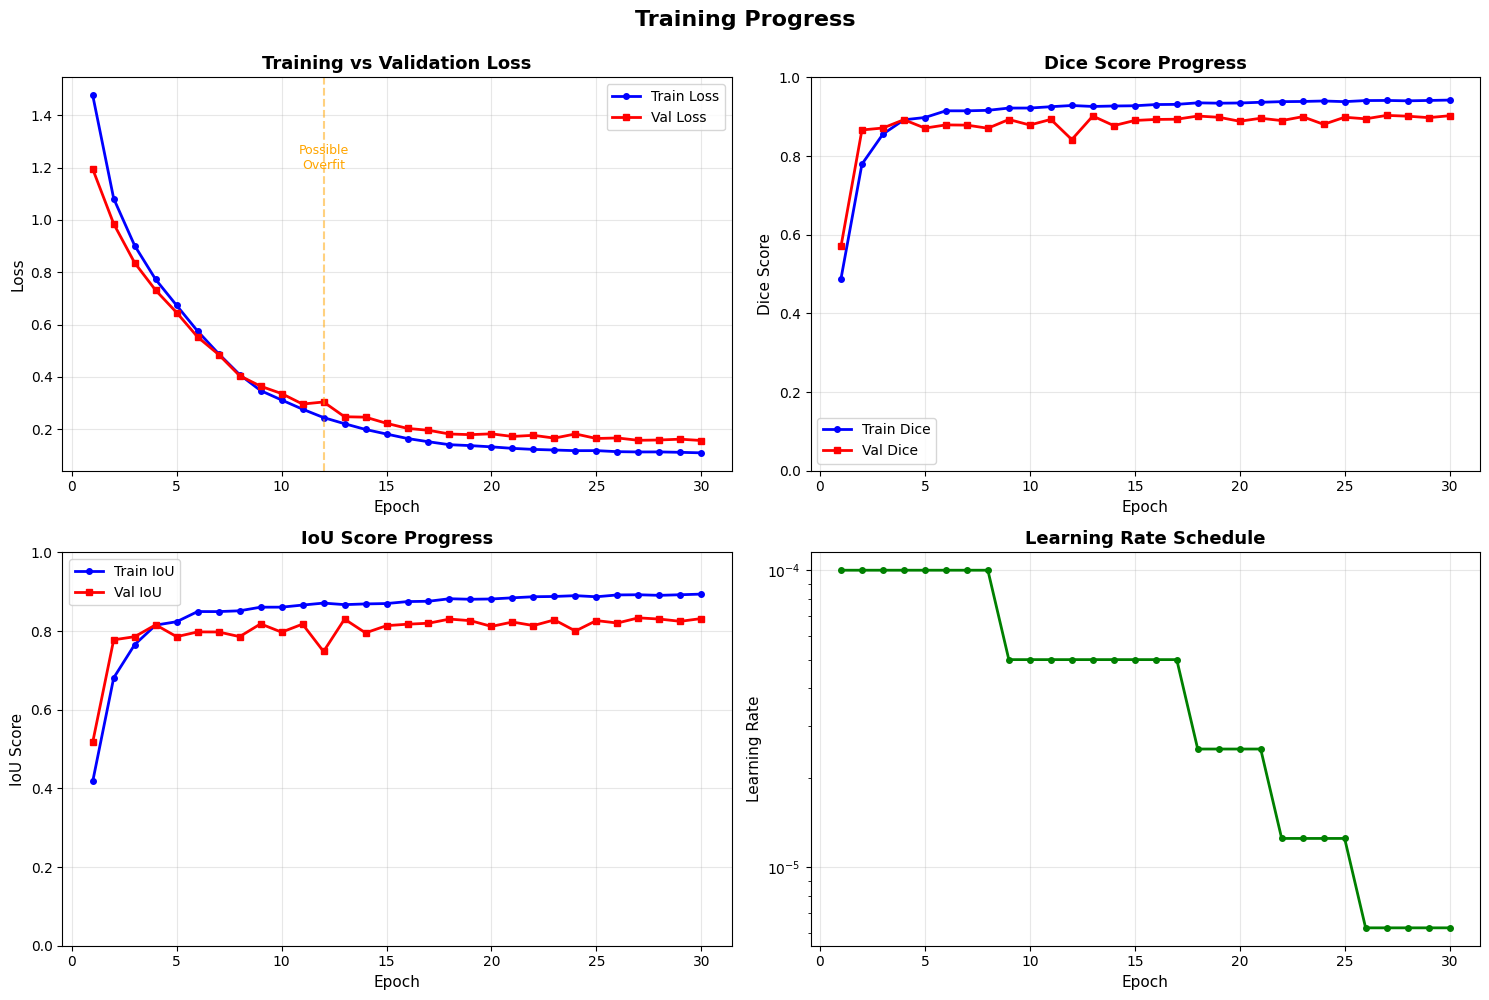


✓ All training logs saved to 'training_logs/' directory


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 2. Función de pérdida

dice_loss = smp.losses.DiceLoss(mode='multiclass')
ce_loss = torch.nn.CrossEntropyLoss()

def criterion(pred, target):
    target_indices = torch.argmax(target, dim=1)
    return dice_loss(pred, target_indices) + ce_loss(pred, target_indices)


# 3. Optimizador y Scheduler
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scaler = torch.cuda.amp.GradScaler()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)
# 4. Configuración del entrenamiento
EPOCHS = 30
best_val_dice = 0.0
save_path = "best_unet_resnet34.pth"

# 5. Inicializar tracker
tracker = TrainingTracker(save_dir='training_logs')

print("="*70)
print("STARTING TRAINING WITH COMPREHENSIVE TRACKING")
print("="*70)
for epoch in range(1, EPOCHS+1):

     # FASE DE ENTRENAMIENTO

    model.train()
    train_loss = 0.0
    train_dice = 0.0
    train_iou = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [TRAIN]")

    for imgs, masks in pbar:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with amp.autocast():
            logits = model(imgs)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()
        train_dice += calculate_dice_score_batch(logits, masks)
        train_iou += calculate_iou_batch(logits, masks)

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = train_loss / len(train_loader)
    avg_train_dice = train_dice / len(train_loader)
    avg_train_iou = train_iou / len(train_loader)

    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0
    val_accuracy = 0.0

    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [VAL]  ", leave=False):
            imgs = imgs.to(device)
            masks = masks.to(device)

            with amp.autocast():
                logits = model(imgs)
                loss = criterion(logits, masks)

             # Calcular métricas
            val_loss += loss.item()
            val_dice += calculate_dice_score_batch(logits, masks)
            val_iou += calculate_iou_batch(logits, masks)

            pred_mask = torch.argmax(logits, dim=1)
            true_mask = torch.argmax(masks, dim=1)
            acc = (pred_mask == true_mask).float().mean()
            val_accuracy += acc.item()
    avg_val_loss = val_loss / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)
    avg_val_iou = val_iou / len(val_loader)
    avg_val_accuracy = val_accuracy / len(val_loader)

    current_lr = optimizer.param_groups[0]['lr']

    tracker.update(
        epoch=epoch,
        train_loss=avg_train_loss,
        train_dice=avg_train_dice,
        train_iou=avg_train_iou,
        val_loss=avg_val_loss,
        val_dice=avg_val_dice,
        val_iou=avg_val_iou,
        val_accuracy=avg_val_accuracy,
        lr=current_lr
    )

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print(f"  Train - Loss: {avg_train_loss:.4f}, Dice: {avg_train_dice:.4f}, IoU: {avg_train_iou:.4f}")
    print(f"  Val   - Loss: {avg_val_loss:.4f}, Dice: {avg_val_dice:.4f}, IoU: {avg_val_iou:.4f}, Acc: {avg_val_accuracy:.4f}")
    print(f"  LR: {current_lr:.6f}")

    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_dice': best_val_dice,
            'train_dice': avg_train_dice,
        }, save_path)
        print(f"  ✓ Model Saved! New Best Val Dice: {best_val_dice:.4f}")
        print()

    scheduler.step(avg_val_dice)
# Guardar checkpoint cada 5 épocas
    if epoch % 5 == 0:
        tracker.save(f'history_epoch_{epoch}.json')


print("\n" + "="*70)
print("TRAINING COMPLETED!")
print("="*70)

tracker.save('training_history_final.json')

# RESUMEN FINAL Y VISUALIZACIÓN
tracker.print_summary()


tracker.plot_training_curves(save_path='training_logs/final_training_curves.png')

print("\n✓ All training logs saved to 'training_logs/' directory")


In [ ]:
print(save_path)

best_unet_resnet34.pth


In [ ]:
class ModelEvaluator:
    """
    Comprehensive evaluation class for semantic segmentation models
    """

    def __init__(self, model, device, num_classes=3, class_names=None):
        """
        Initialize the evaluator

        Args:
            model: PyTorch segmentation model
            device: torch.device for computation
            num_classes: Number of segmentation classes
            class_names: List of class names for visualization
        """
        self.model = model
        self.device = device
        self.num_classes = num_classes
        self.class_names = class_names or [f'Class {i}' for i in range(num_classes)]
        self.results = None

    def calculate_dice_score(self, pred: np.ndarray, target: np.ndarray, class_idx: int) -> float:
        """Calculate Dice score for a specific class"""
        pred_class = (pred == class_idx)
        target_class = (target == class_idx)

        intersection = (pred_class & target_class).sum()
        union = pred_class.sum() + target_class.sum()

        if union == 0:
            return 1.0 if intersection == 0 else 0.0

        dice = (2.0 * intersection) / union
        return dice

    def calculate_iou(self, pred: np.ndarray, target: np.ndarray, class_idx: int) -> float:
        """Calculate IoU (Jaccard) for a specific class"""
        pred_class = (pred == class_idx)
        target_class = (target == class_idx)

        intersection = (pred_class & target_class).sum()
        union = (pred_class | target_class).sum()

        if union == 0:
            return 1.0 if intersection == 0 else 0.0

        iou = intersection / union
        return iou

    def calculate_pixel_accuracy(self, pred: np.ndarray, target: np.ndarray) -> float:
        """Calculate overall pixel accuracy"""
        correct = (pred == target).sum()
        total = pred.size
        return correct / total

    def calculate_precision_recall(self, pred: np.ndarray, target: np.ndarray, class_idx: int) -> Tuple[float, float]:
        """Calculate precision and recall for a specific class"""
        pred_class = (pred == class_idx)
        target_class = (target == class_idx)

        tp = (pred_class & target_class).sum()
        fp = (pred_class & ~target_class).sum()
        fn = (~pred_class & target_class).sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        return precision, recall

    def evaluate(self, dataloader, verbose=True) -> Dict:
        """
        Memory-optimized evaluation for Google Colab
        """
        self.model.eval()

        # Acumuladores de métricas
        dice_scores = {i: [] for i in range(self.num_classes)}
        iou_scores = {i: [] for i in range(self.num_classes)}
        precision_scores = {i: [] for i in range(self.num_classes)}
        recall_scores = {i: [] for i in range(self.num_classes)}
        pixel_accuracies = []

      # Acumulador de matriz de confusión
        conf_matrix = np.zeros((self.num_classes, self.num_classes), dtype=np.int64)

        iterator = tqdm(dataloader, desc="Evaluating") if verbose else dataloader

        with torch.no_grad():
            for imgs, masks in iterator:


                # Mover imágenes a la GPU
                imgs = imgs.to(self.device)

                # Las máscaras deben mantenerse en CPU
                true_masks = masks.numpy()

                # (GPU)
                logits = self.model(imgs)

                if len(true_masks.shape) == 4 and true_masks.shape[1] > 1:
                    true_masks = np.argmax(true_masks, axis=1)


               # Predicción → CPU
                pred_masks = torch.argmax(logits, dim=1).cpu().numpy()

                for pred, target in zip(pred_masks, true_masks):

                    pixel_accuracies.append(
                        self.calculate_pixel_accuracy(pred, target)
                    )

                    for class_idx in range(self.num_classes):
                        dice_scores[class_idx].append(
                            self.calculate_dice_score(pred, target, class_idx)
                        )
                        iou_scores[class_idx].append(
                            self.calculate_iou(pred, target, class_idx)
                        )
                        prec, rec = self.calculate_precision_recall(
                            pred, target, class_idx
                        )
                        precision_scores[class_idx].append(prec)
                        recall_scores[class_idx].append(rec)


                    # Actualizar matriz de confusión incrementalmente
                    cm = confusion_matrix(
                        target.flatten(),
                        pred.flatten(),
                        labels=list(range(self.num_classes))
                    )
                    conf_matrix += cm

        ## Resultados finales agregados
        self.results = {
            'pixel_accuracy': np.mean(pixel_accuracies),
            'dice_per_class': {i: np.mean(dice_scores[i]) for i in range(self.num_classes)},
            'iou_per_class': {i: np.mean(iou_scores[i]) for i in range(self.num_classes)},
            'precision_per_class': {i: np.mean(precision_scores[i]) for i in range(self.num_classes)},
            'recall_per_class': {i: np.mean(recall_scores[i]) for i in range(self.num_classes)},
            'mean_dice': np.mean([np.mean(dice_scores[i]) for i in range(self.num_classes)]),
            'mean_iou': np.mean([np.mean(iou_scores[i]) for i in range(self.num_classes)]),
            'mean_precision': np.mean([np.mean(precision_scores[i]) for i in range(self.num_classes)]),
            'mean_recall': np.mean([np.mean(recall_scores[i]) for i in range(self.num_classes)]),
            'confusion_matrix': conf_matrix
        }

        return self.results


    def print_results(self):
        """Print formatted results"""
        if self.results is None:
            print("No results available. Run evaluate() first.")
            return

        print("\n" + "="*70)
        print("EVALUATION RESULTS")
        print("="*70)

        print(f"\nOverall Metrics:")
        print(f"  Pixel Accuracy:     {self.results['pixel_accuracy']:.4f}")
        print(f"  Mean Dice Score:    {self.results['mean_dice']:.4f}")
        print(f"  Mean IoU:           {self.results['mean_iou']:.4f}")
        print(f"  Mean Precision:     {self.results['mean_precision']:.4f}")
        print(f"  Mean Recall:        {self.results['mean_recall']:.4f}")

        print(f"\nPer-Class Metrics:")
        print(f"{'Class':<15} {'Dice':<10} {'IoU':<10} {'Precision':<10} {'Recall':<10}")
        print("-" * 70)
        for i in range(self.num_classes):
            print(f"{self.class_names[i]:<15} "
                  f"{self.results['dice_per_class'][i]:<10.4f} "
                  f"{self.results['iou_per_class'][i]:<10.4f} "
                  f"{self.results['precision_per_class'][i]:<10.4f} "
                  f"{self.results['recall_per_class'][i]:<10.4f}")

    def plot_confusion_matrix(self, save_path: Optional[str] = None, figsize=(14, 5)):
        """Plot confusion matrix"""
        if self.results is None:
            print("No results available. Run evaluate() first.")
            return

        cm = self.results['confusion_matrix']
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        fig, axes = plt.subplots(1, 2, figsize=figsize)


        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=self.class_names, yticklabels=self.class_names, ax=axes[0])
        axes[0].set_title('Confusion Matrix (Counts)')
        axes[0].set_ylabel('True Label')
        axes[0].set_xlabel('Predicted Label')


        sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
                    xticklabels=self.class_names, yticklabels=self.class_names, ax=axes[1])
        axes[1].set_title('Confusion Matrix (Normalized)')
        axes[1].set_ylabel('True Label')
        axes[1].set_xlabel('Predicted Label')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Confusion matrix saved to: {save_path}")

        plt.show()

    def plot_metrics_bar_chart(self, save_path: Optional[str] = None, figsize=(16, 5)):
        """Plot bar charts for all metrics"""
        if self.results is None:
            print("No results available. Run evaluate() first.")
            return

        fig, axes = plt.subplots(1, 3, figsize=figsize)

        # Dice scores
        dice_values = [self.results['dice_per_class'][i] for i in range(self.num_classes)]
        axes[0].bar(self.class_names, dice_values, color=['gray', 'green', 'red'], alpha=0.7)
        axes[0].axhline(y=self.results['mean_dice'], color='blue', linestyle='--',
                        label=f'Mean: {self.results["mean_dice"]:.3f}')
        axes[0].set_ylabel('Score')
        axes[0].set_title('Dice Score per Class')
        axes[0].set_ylim(0, 1)
        axes[0].legend()
        axes[0].grid(axis='y', alpha=0.3)
        axes[0].tick_params(axis='x', rotation=45)

        # IoU scores
        iou_values = [self.results['iou_per_class'][i] for i in range(self.num_classes)]
        axes[1].bar(self.class_names, iou_values, color=['gray', 'green', 'red'], alpha=0.7)
        axes[1].axhline(y=self.results['mean_iou'], color='blue', linestyle='--',
                        label=f'Mean: {self.results["mean_iou"]:.3f}')
        axes[1].set_ylabel('Score')
        axes[1].set_title('IoU Score per Class')
        axes[1].set_ylim(0, 1)
        axes[1].legend()
        axes[1].grid(axis='y', alpha=0.3)
        axes[1].tick_params(axis='x', rotation=45)

        # Precision & Recall
        precision_values = [self.results['precision_per_class'][i] for i in range(self.num_classes)]
        recall_values = [self.results['recall_per_class'][i] for i in range(self.num_classes)]

        x = np.arange(len(self.class_names))
        width = 0.35

        axes[2].bar(x - width/2, precision_values, width, label='Precision', alpha=0.7)
        axes[2].bar(x + width/2, recall_values, width, label='Recall', alpha=0.7)
        axes[2].set_ylabel('Score')
        axes[2].set_title('Precision & Recall per Class')
        axes[2].set_xticks(x)
        axes[2].set_xticklabels(self.class_names, rotation=45)
        axes[2].set_ylim(0, 1)
        axes[2].legend()
        axes[2].grid(axis='y', alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Metrics chart saved to: {save_path}")

        plt.show()

    def visualize_predictions(self, dataset, num_samples=5, save_path: Optional[str] = None):
        """Visualize model predictions on sample images"""
        self.model.eval()


        # Seleccionar muestras aleatorias
        indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)

        fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))

        if num_samples == 1:
            axes = axes.reshape(1, -1)

        for i, idx in enumerate(indices):
            # Cargar imagen original
            img_path = dataset.images[idx]
            img_orig = cv2.imread(img_path)
            img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
            img_orig = cv2.resize(img_orig, (512, 512))

           # Obtener predicción
            img_tensor, mask_tensor = dataset[idx]
            img_tensor = img_tensor.unsqueeze(0).to(self.device)

            with torch.no_grad():
                logits = self.model(img_tensor)
                pred_mask = torch.argmax(logits, dim=1).cpu().numpy()[0]

           # Ground truth (máscara real)
            true_mask = torch.argmax(mask_tensor, dim=0).numpy()

            # Calcular métricas para esta imagen
            dice_scores = [self.calculate_dice_score(pred_mask, true_mask, c)
                          for c in range(self.num_classes)]
            iou_scores = [self.calculate_iou(pred_mask, true_mask, c)
                         for c in range(self.num_classes)]

            # Crear superposiciones coloreadas
            def create_overlay(img, mask):
                overlay = img.copy()
                colored = np.zeros_like(img)
                colored[mask == 0] = [255, 255, 255]  # White for Background
                colored[mask == 1] = [0, 255, 0]  # Green for Disc
                colored[mask == 2] = [255, 0, 0]  # Red for Cup
                return cv2.addWeighted(overlay, 0.6, colored, 0.4, 0)

            # Plot
            axes[i, 0].imshow(img_orig)
            axes[i, 0].set_title('Original Image')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(true_mask, cmap='gray', vmin=0, vmax=self.num_classes-1)
            axes[i, 1].set_title('Ground Truth')
            axes[i, 1].axis('off')

            axes[i, 2].imshow(pred_mask, cmap='gray', vmin=0, vmax=self.num_classes-1)
            dice_text = ", ".join([f"{self.class_names[c]}: {dice_scores[c]:.3f}"
                                  for c in range(1, self.num_classes)])
            axes[i, 2].set_title(f'Prediction\nDice - {dice_text}')
            axes[i, 2].axis('off')

            overlay_pred = create_overlay(img_orig, pred_mask)
            iou_text = ", ".join([f"{self.class_names[c]}: {iou_scores[c]:.3f}"
                                 for c in range(1, self.num_classes)])
            axes[i, 3].imshow(overlay_pred)
            axes[i, 3].set_title(f'Overlay\nIoU - {iou_text}')
            axes[i, 3].axis('off')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Predictions saved to: {save_path}")

        plt.show()

    def save_results(self, filepath: str):
        """Save evaluation results to a text file"""
        if self.results is None:
            print("No results available. Run evaluate() first.")
            return

        with open(filepath, 'w') as f:
            f.write("="*70 + "\n")
            f.write("EVALUATION RESULTS\n")
            f.write("="*70 + "\n\n")

            f.write(f"Overall Metrics:\n")
            f.write(f"  Pixel Accuracy:     {self.results['pixel_accuracy']:.4f}\n")
            f.write(f"  Mean Dice Score:    {self.results['mean_dice']:.4f}\n")
            f.write(f"  Mean IoU:           {self.results['mean_iou']:.4f}\n")
            f.write(f"  Mean Precision:     {self.results['mean_precision']:.4f}\n")
            f.write(f"  Mean Recall:        {self.results['mean_recall']:.4f}\n\n")

            f.write(f"Per-Class Metrics:\n")
            f.write(f"{'Class':<15} {'Dice':<10} {'IoU':<10} {'Precision':<10} {'Recall':<10}\n")
            f.write("-" * 70 + "\n")
            for i in range(self.num_classes):
                f.write(f"{self.class_names[i]:<15} "
                       f"{self.results['dice_per_class'][i]:<10.4f} "
                       f"{self.results['iou_per_class'][i]:<10.4f} "
                       f"{self.results['precision_per_class'][i]:<10.4f} "
                       f"{self.results['recall_per_class'][i]:<10.4f}\n")

        print(f"Results saved to: {filepath}")

    def generate_report(self, output_dir: str = "evaluation_results"):
        """Generate complete evaluation report with all visualizations"""
        if self.results is None:
            print("No results available. Run evaluate() first.")
            return

        os.makedirs(output_dir, exist_ok=True)

        # Save text results
        self.save_results(os.path.join(output_dir, "results.txt"))

        # Save confusion matrix
        self.plot_confusion_matrix(save_path=os.path.join(output_dir, "confusion_matrix.png"))

        # Save metrics chart
        self.plot_metrics_bar_chart(save_path=os.path.join(output_dir, "metrics_chart.png"))

        print(f"\n✓ Complete evaluation report generated in: {output_dir}/")

    def compare_datasets(self, train_loader, val_loader, test_loader, dataset_names=['Train', 'Validation', 'Test']):
        """
        Compare model performance across multiple datasets to detect overfitting

        Args:
            train_loader: DataLoader for training set
            val_loader: DataLoader for validation set
            test_loader: DataLoader for test set
            dataset_names: Names for each dataset
        """
        results_comparison = {}

        print("\n" + "="*70)
        print("OVERFITTING ANALYSIS - Comparing Datasets")
        print("="*70 + "\n")


        for loader, name in zip([train_loader, val_loader, test_loader], dataset_names):
            print(f"Evaluating on {name} set...")
            results = self.evaluate(loader, verbose=False)
            results_comparison[name] = results


        print("\n" + "="*70)
        print("PERFORMANCE COMPARISON")
        print("="*70)

        metrics = ['pixel_accuracy', 'mean_dice', 'mean_iou', 'mean_precision', 'mean_recall']
        metric_names = ['Pixel Accuracy', 'Mean Dice', 'Mean IoU', 'Mean Precision', 'Mean Recall']


        print(f"\n{'Metric':<20} {dataset_names[0]:<12} {dataset_names[1]:<12} {dataset_names[2]:<12} {'Gap (Train-Test)':<15}")
        print("-" * 70)

        for metric, name in zip(metrics, metric_names):
            train_val = results_comparison[dataset_names[0]][metric]
            val_val = results_comparison[dataset_names[1]][metric]
            test_val = results_comparison[dataset_names[2]][metric]
            gap = train_val - test_val

            print(f"{name:<20} {train_val:<12.4f} {val_val:<12.4f} {test_val:<12.4f} {gap:<15.4f}")


        print(f"\n{'Class Dice Scores':<20} {dataset_names[0]:<12} {dataset_names[1]:<12} {dataset_names[2]:<12}")
        print("-" * 70)

        for i, class_name in enumerate(self.class_names):
            train_dice = results_comparison[dataset_names[0]]['dice_per_class'][i]
            val_dice = results_comparison[dataset_names[1]]['dice_per_class'][i]
            test_dice = results_comparison[dataset_names[2]]['dice_per_class'][i]

            print(f"{class_name:<20} {train_dice:<12.4f} {val_dice:<12.4f} {test_dice:<12.4f}")

       # Indicadores de sobreajuste
        print("\n" + "="*70)
        print("OVERFITTING INDICATORS")
        print("="*70)

        train_dice = results_comparison[dataset_names[0]]['mean_dice']
        test_dice = results_comparison[dataset_names[2]]['mean_dice']
        gap = train_dice - test_dice

        print(f"\nDice Score Gap (Train - Test): {gap:.4f}")

        if gap < 0.05:
            status = "✓ NO OVERFITTING"
            print(f"Status: {status}")
            print("The model generalizes well to unseen data.")
        elif gap < 0.10:
            status = "⚠ SLIGHT OVERFITTING"
            print(f"Status: {status}")
            print("Minor overfitting detected. Model may benefit from:")
            print("  - More data augmentation")
            print("  - Slight regularization (dropout, weight decay)")
        else:
            status = "✗ SIGNIFICANT OVERFITTING"
            print(f"Status: {status}")
            print("Significant overfitting detected. Consider:")
            print("  - Stronger data augmentation")
            print("  - Dropout layers")
            print("  - L2 regularization (weight decay)")
            print("  - Early stopping")
            print("  - Reducing model complexity")


        val_dice = results_comparison[dataset_names[1]]['mean_dice']
        val_test_gap = abs(val_dice - test_dice)

        print(f"\nValidation-Test Consistency: {val_test_gap:.4f}")
        if val_test_gap < 0.03:
            print("✓ Good consistency - validation set is representative")
        else:
            print("⚠ Poor consistency - validation set may not be representative")

        return results_comparison

    def plot_dataset_comparison(self, results_comparison, save_path=None):
        """Plot comparison of metrics across datasets"""

        dataset_names = list(results_comparison.keys())
        metrics = ['mean_dice', 'mean_iou', 'mean_precision', 'mean_recall']
        metric_labels = ['Mean Dice', 'Mean IoU', 'Mean Precision', 'Mean Recall']

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.flatten()

        colors = ['#2ecc71', '#3498db', '#e74c3c']

        for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
            values = [results_comparison[ds][metric] for ds in dataset_names]

            bars = axes[idx].bar(dataset_names, values, color=colors, alpha=0.7, edgecolor='black')
            axes[idx].set_ylabel('Score')
            axes[idx].set_title(label)
            axes[idx].set_ylim(0, 1)
            axes[idx].grid(axis='y', alpha=0.3)

            # Añadir etiquetas sobre las barras
            for bar, val in zip(bars, values):
                height = bar.get_height()
                axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

            #  Resaltar sobreajuste si el rendimiento en train > test de forma significativa
            if len(values) >= 3 and (values[0] - values[2]) > 0.05:
                axes[idx].axhline(y=values[2], color='red', linestyle='--',
                                alpha=0.5, label=f'Gap: {values[0]-values[2]:.4f}')
                axes[idx].legend()

        plt.suptitle('Performance Comparison Across Datasets', fontsize=16, fontweight='bold')
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Comparison plot saved to: {save_path}")

        plt.show()

Evaluating: 100%|██████████| 100/100 [00:47<00:00,  2.12it/s]



EVALUATION RESULTS

Overall Metrics:
  Pixel Accuracy:     0.9972
  Mean Dice Score:    0.9154
  Mean IoU:           0.8540
  Mean Precision:     0.9078
  Mean Recall:        0.9330

Per-Class Metrics:
Class           Dice       IoU        Precision  Recall    
----------------------------------------------------------------------
Background      0.9991     0.9982     0.9993     0.9989    
Optic Disc      0.8780     0.7888     0.8683     0.8960    
Optic Cup       0.8690     0.7750     0.8558     0.9040    
Results saved to: my_test_results/results.txt
Confusion matrix saved to: my_test_results/confusion_matrix.png


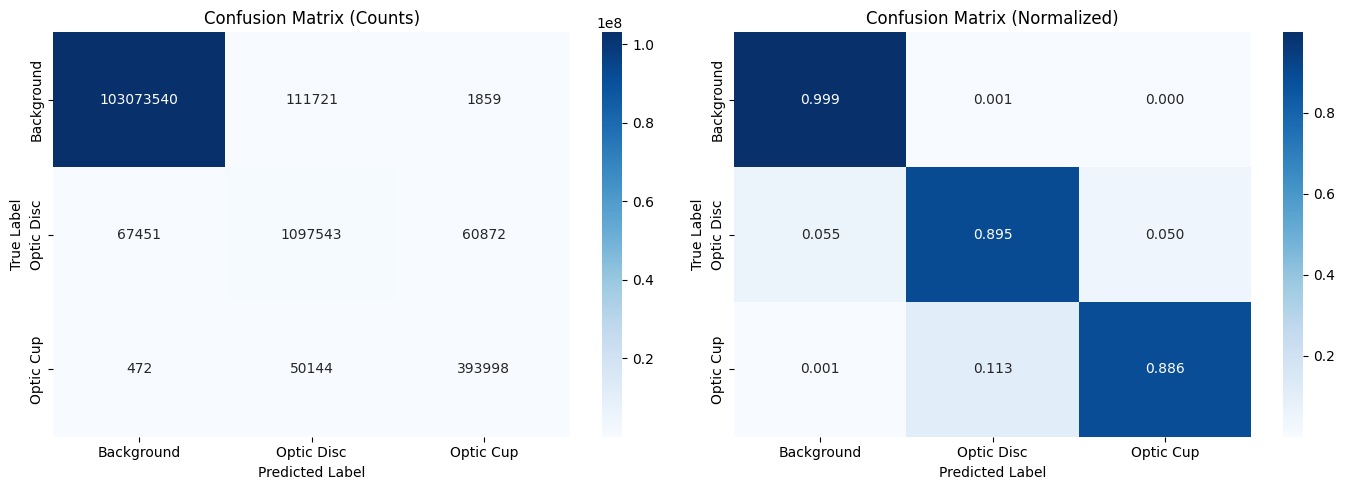

Metrics chart saved to: my_test_results/metrics_chart.png


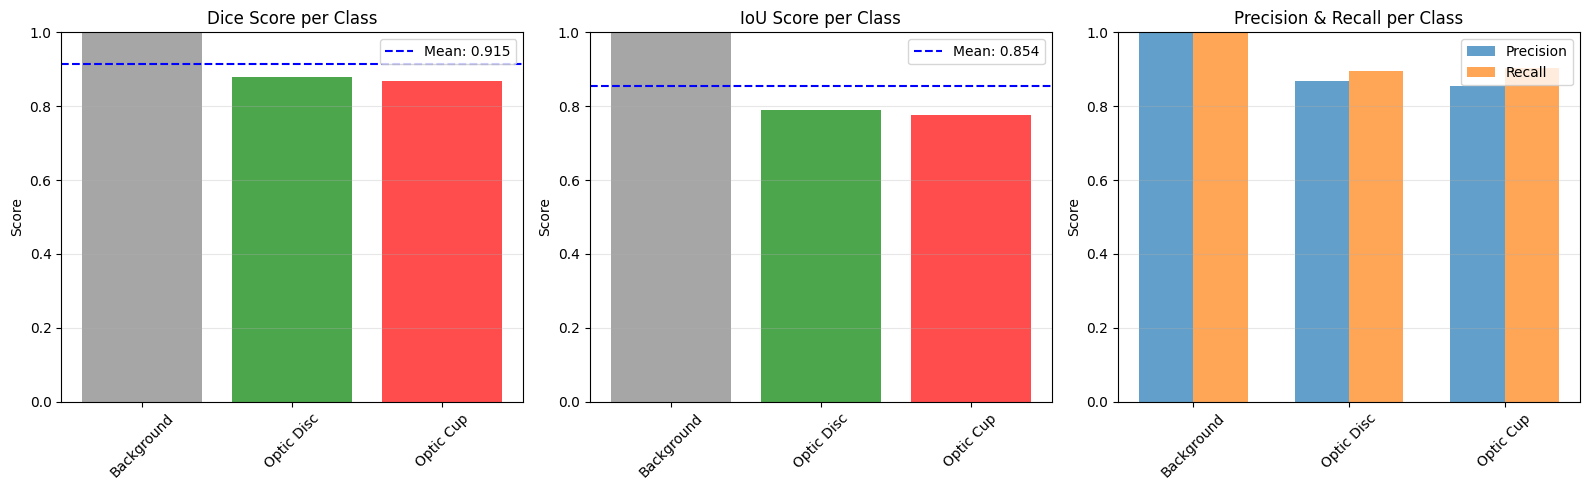


✓ Complete evaluation report generated in: my_test_results/
Predictions saved to: predictions.png


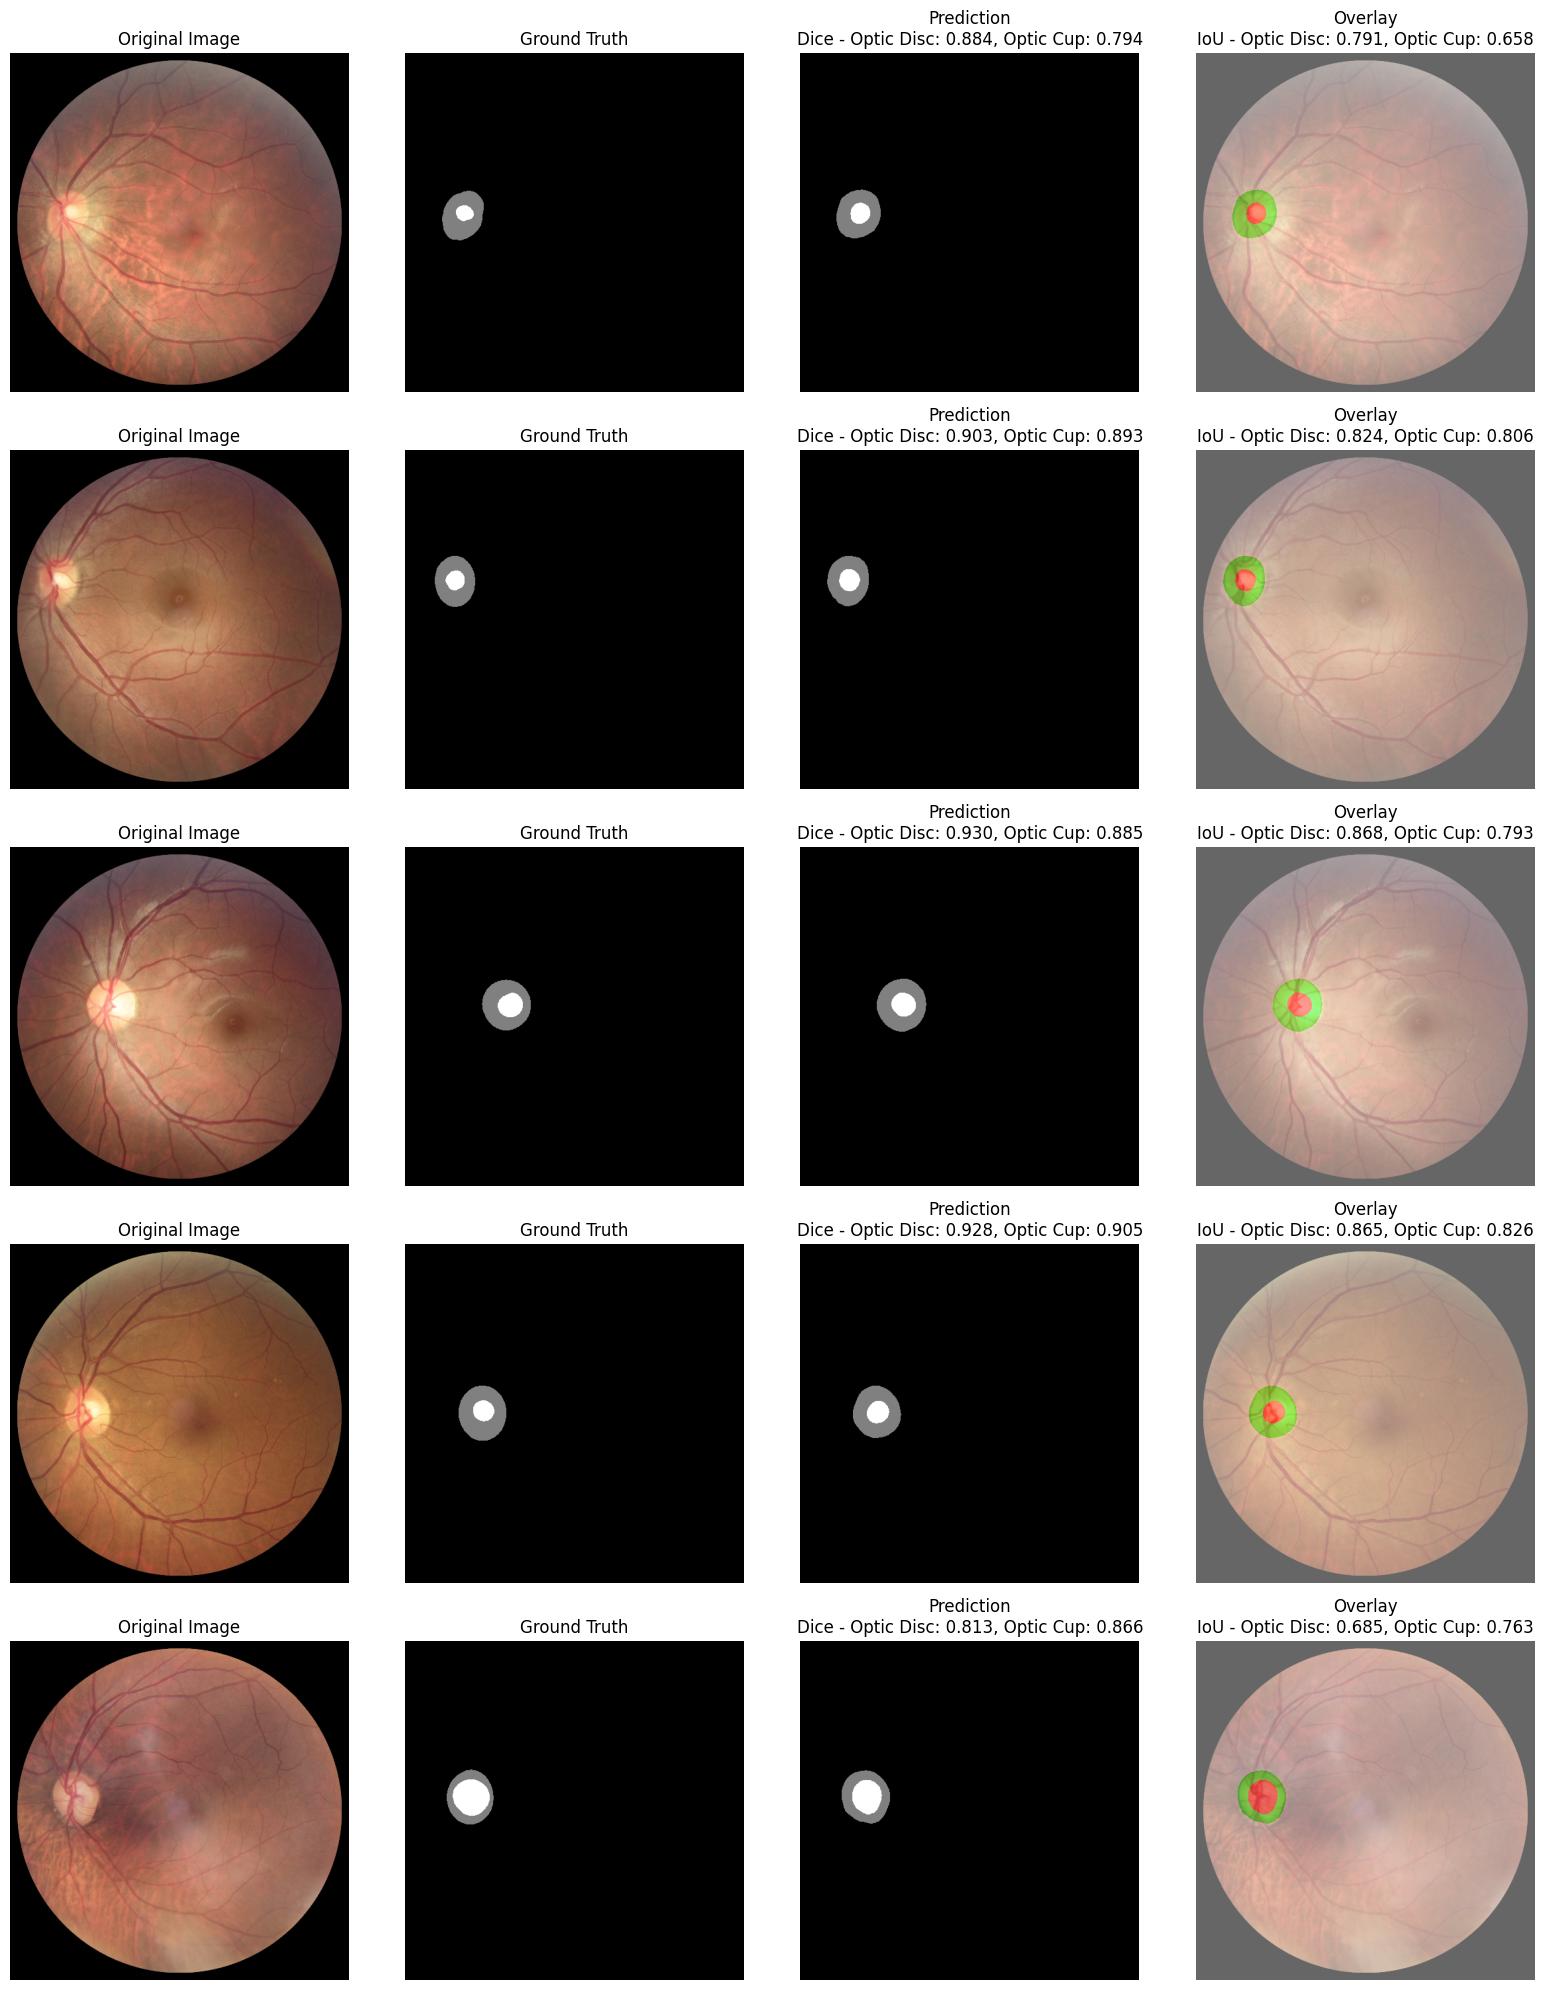

In [ ]:
# 1. Create test dataset and dataloader
test_ds = FundusSegDataset(test_images, test_masks, transforms=None, img_size=512)
test_loader = DataLoader(
    test_ds,
    batch_size=4,      # ↓ reduce RAM
    shuffle=False,
    num_workers=0,     # ← CRÍTICO en Colab
    pin_memory=False   # reduce requisitos
)

evaluator = ModelEvaluator(model, device, 3, ['Background', 'Optic Disc', 'Optic Cup'])
evaluator.evaluate(test_loader)
evaluator.print_results()
evaluator.generate_report("my_test_results")
evaluator.visualize_predictions(test_ds, num_samples=5, save_path="predictions.png")

In [ ]:
import numpy as np
import torch
import pandas as pd
from tqdm import tqdm


#  FUNCIÓN DE CDR MODIFICADA

def compute_CDR_info(mask_tensor):

    if isinstance(mask_tensor, torch.Tensor):
        mask = mask_tensor.detach().cpu().numpy()
    else:
        mask = mask_tensor

    disc = (mask == 1).astype(np.uint8)
    cup  = (mask == 2).astype(np.uint8)

    def height(m):
        ys = np.where(m > 0)[0]
        if len(ys) == 0:
            return 0
        return ys.max() - ys.min() + 1

    h_disc = height(disc)
    h_cup  = height(cup)

    if h_disc == 0:
        return None, 0, 0 # CDR, h_disc, h_cup

    # CDR calculado a partir de valores medidos, clamped a 1.0
    h_cup_clamped = min(h_cup, h_disc) # Ensure CDR is <= 1
    CDR = h_cup_clamped / h_disc

    return CDR, h_disc, h_cup


#  RECORRER EL TEST LOADER Y CALCULAR CDRs

results = {
    "Image_ID": [],
    "CDR_pred": [],
    "CDR_true": [],
    "Disc_pred_h": [],
    "Cup_pred_h": [],
    "Disc_true_h": [],
    "Cup_true_h": []
}

model.eval()

with torch.no_grad():
    img_id = 0

    for imgs, masks in tqdm(test_loader, desc="Computing CDR values"):

        imgs = imgs.to(device)
        masks = masks.to(device)

        # ---- Predicción ----
        logits = model(imgs)
        pred_masks = torch.argmax(logits, dim=1)  # (B, H, W)
        true_masks = torch.argmax(masks, dim=1)   # (B, H, W)

        # ---- Procesar cada imagen del batch ----
        for i in range(pred_masks.shape[0]):

            pred_mask = pred_masks[i]
            true_mask = true_masks[i]

            # Cálculo para predicción
            CDR_p, disc_p, cup_p = compute_CDR_info(pred_mask)

            # Cálculo para máscara real
            CDR_t, disc_t, cup_t = compute_CDR_info(true_mask)

            # Guardar resultados
            results["Image_ID"].append(img_id)
            results["CDR_pred"].append(CDR_p)
            results["CDR_true"].append(CDR_t)
            results["Disc_pred_h"].append(disc_p)
            results["Cup_pred_h"].append(cup_p)
            results["Disc_true_h"].append(disc_t)
            results["Cup_true_h"].append(cup_t)

            img_id += 1



#  CREAR TABLA FINAL

df_cdr = pd.DataFrame(results)

df_cdr = df_cdr.dropna(subset=['CDR_pred', 'CDR_true']).reset_index(drop=True)
df_cdr

Computing CDR values: 100%|██████████| 100/100 [00:32<00:00,  3.10it/s]


,Image_ID,CDR_pred,CDR_true,Disc_pred_h,Cup_pred_h,Disc_true_h,Cup_true_h
0,0,0.452055,0.500000,73,33,76,38
1,1,0.450704,0.348485,71,32,66,23
2,2,0.500000,0.520548,74,37,73,38
3,3,0.532609,0.478723,92,49,94,45
4,4,0.389610,0.407895,77,30,76,31
...,...,...,...,...,...,...,...
395,395,0.432432,0.360000,74,32,75,27
396,396,0.675000,0.769231,80,54,78,60
397,397,0.475000,0.597561,80,38,82,49
398,398,0.445946,0.487179,74,33,78,38


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!mkdir -p /content/drive/MyDrive/MisModelos1


In [ ]:
!cp /content/best_unet_resnet34.pth /content/drive/MyDrive/MisModelos1/
